# Model - XGBoost (Member 3)

**Task:** predict `y` (term deposit subscription) *before* a call is made, so `duration` is not used.
**Pipeline:** `CampaignFeatures` -> one-hot encoding -> `XGBClassifier` (all inside one sklearn `Pipeline`, so the backend applies exactly the same steps).

**This notebook (part 1)** builds the *untuned* baseline and checks it on both splits from our proposal. Tuning (RandomizedSearchCV and Optuna) comes in part 2.

**Metric:** PR-AUC (average precision) is the main metric because only 11% of clients subscribe. ROC-AUC, recall, precision, F1 and the confusion matrix are reported too. A random classifier scores a PR-AUC equal to the positive rate - that is the "floor" we compare against.

## 0. Setup

In [1]:
import csv
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# make `src` importable when the notebook runs from /notebooks
sys.path.append(str(Path.cwd().parent))
from src.config import EXPERIMENT_LOG, RAW_DATA, ROOT
from src.data_cleaning import clean_and_split
from src.lr_model import INPUT_COLUMNS, build_lr_pipeline, chronological_split, load_data
from src.xgb_model import build_xgb_pipeline, compute_scale_pos_weight, cv_summary, evaluate_at_threshold

# Member 1's build_lr_pipeline passes l1_ratio together with an L2 penalty; sklearn warns that it is ignored (harmless)
warnings.filterwarnings("ignore", message="l1_ratio parameter is only used when penalty is 'elasticnet'")

FIG_DIR = ROOT / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

BLUE, ORANGE, GREY, LIGHT = "#2a78d6", "#eb6834", "#52514e", "#d9d8d2"   # XGBoost / Logistic Regression / reference / grid
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": LIGHT, "grid.linewidth": 0.6, "axes.grid.axis": "y",
})
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")


def save_fig(name):
    """Save the current figure into results/figures with the xgb_ prefix."""
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"xgb_{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 1. Two splits

Our proposal defines two ways to hold out data:

* **Chronological hold-out (primary):** the file is ordered by date, so the *last 20%* of the rows are the test set. This mimics the real use: train on the past, predict later campaigns.
* **Stratified random split (secondary):** a random 80/20 split that keeps the class balance. The proposal keeps it only to *show the effect of temporal shift*.

In both, duplicates are removed **before** `duration` is dropped (the shared `remove_duplicates` order), and the test set is not used for any tuning decision.

In [2]:
# chronological (primary): shared loader from src/lr_model.py - duplicates removed first, duration dropped, date order kept
X, y = load_data()
assert "duration" not in X.columns                      # leakage check: the model never sees the call length
X_tr_c, X_te_c, y_tr_c, y_te_c = chronological_split(X, y)

# stratified (secondary): Member 2's shared split from src/data_cleaning.py
raw = pd.read_csv(RAW_DATA, sep=";")
X_tr_s, X_te_s, y_tr_s, y_te_s = clean_and_split(raw)
y_tr_s, y_te_s = (y_tr_s == "yes").astype(int), (y_te_s == "yes").astype(int)
X_tr_s, X_te_s = X_tr_s[INPUT_COLUMNS], X_te_s[INPUT_COLUMNS]

pd.DataFrame({
    "train rows": [len(X_tr_c), len(X_tr_s)], "test rows": [len(X_te_c), len(X_te_s)],
    "train yes-rate": [y_tr_c.mean(), y_tr_s.mean()], "test yes-rate": [y_te_c.mean(), y_te_s.mean()],
    "scale_pos_weight": [compute_scale_pos_weight(y_tr_c), compute_scale_pos_weight(y_tr_s)],
}, index=["chronological (primary)", "stratified (secondary)"])

,train rows,test rows,train yes-rate,test yes-rate,scale_pos_weight
chronological (primary),32940,8236,0.0638,0.3083,14.6857
stratified (secondary),32940,8236,0.1127,0.1127,7.8763


### Insight -> decision

- Finding: in the chronological split the **training part has 6.4% subscribers but the test part has 30.8%** - a big shift in class balance over time. The stratified split keeps 11.3% in both.
- Decision: report both splits. The chronological one is the main result; the stratified one shows what a random split would have hidden.
- Reason: `scale_pos_weight` (negatives / positives of the *training* labels) is **14.7** for the chronological split, not the 7.9 you get from a stratified split - it must always be computed from the training part of the split being used.

## 2. Baseline model = XGBoost with default settings

No tuning yet: the default XGBoost settings (100 trees, depth 6, learning rate 0.3) plus `scale_pos_weight` to give the rare "yes" class more weight. The Logistic Regression baseline from Member 1 (`build_lr_pipeline()`, default settings) is run on the same data for comparison.

In [3]:
def run_model(name, pipeline, X_tr, y_tr, X_te, y_te):
    """Stratified 5-fold CV on the TRAINING part, then one evaluation on the test part at threshold 0.5."""
    cv = cv_summary(pipeline, X_tr, y_tr)
    pipeline.fit(X_tr, y_tr)
    proba = pipeline.predict_proba(X_te)[:, 1]
    return {"name": name, "pipeline": pipeline, "proba": proba, "cv": cv, "test": evaluate_at_threshold(y_te, proba, 0.5)}


results = {}
for split, (X_tr, y_tr, X_te, y_te) in {"chronological": (X_tr_c, y_tr_c, X_te_c, y_te_c),
                                        "stratified": (X_tr_s, y_tr_s, X_te_s, y_te_s)}.items():
    results[split, "XGBoost"] = run_model("XGBoost", build_xgb_pipeline(compute_scale_pos_weight(y_tr)), X_tr, y_tr, X_te, y_te)
    results[split, "Logistic Regression"] = run_model("Logistic Regression", build_lr_pipeline(), X_tr, y_tr, X_te, y_te)

rows = []
for (split, model), r in results.items():
    floor = (y_te_c if split == "chronological" else y_te_s).mean()
    rows.append({"split": split, "model": model,
                 "CV PR-AUC": r["cv"]["cv_pr_auc_mean"], "CV std": r["cv"]["cv_pr_auc_std"],
                 "test PR-AUC": r["test"]["pr_auc"], "test ROC-AUC": r["test"]["roc_auc"],
                 "recall": r["test"]["recall"], "precision": r["test"]["precision"], "F1": r["test"]["f1"],
                 "floor PR-AUC": floor})
summary = pd.DataFrame(rows).set_index(["split", "model"])
summary

CV PR-AUC  CV std  test PR-AUC  \
split         model                                                 
chronological XGBoost                 0.1805  0.0141       0.3666   
              Logistic Regression     0.2027  0.0251       0.5052   
stratified    XGBoost                 0.4270  0.0112       0.4536   
              Logistic Regression     0.4462  0.0130       0.4475   

                                   test ROC-AUC  recall  precision     F1  \
split         model                                                         
chronological XGBoost                    0.5612  0.1776     0.4002 0.2460   
              Logistic Regression        0.7007  0.8476     0.3599 0.5053   
stratified    XGBoost                    0.7954  0.6336     0.3836 0.4779   
              Logistic Regression        0.8009  0.6498     0.3626 0.4655   

                                   floor PR-AUC  
split         model                              
chronological XGBoost                    0.3083  
              Logistic Regression        0.3083  
stratified    XGBoost                    0.1127  
              Logistic Regression        0.1127

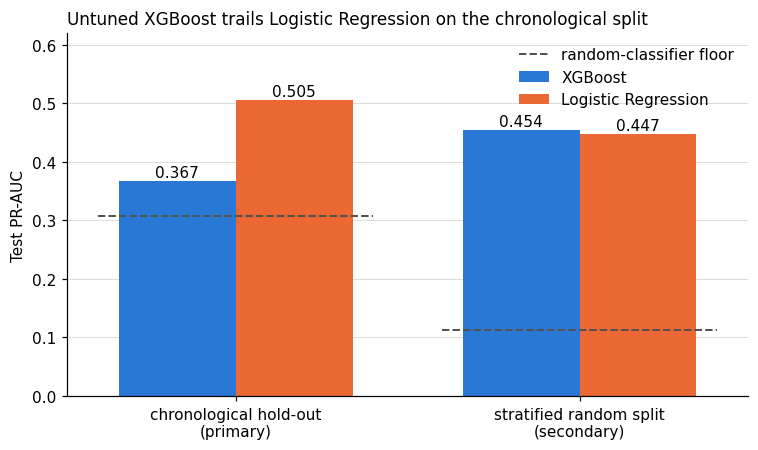

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.2))
width = 0.34
for i, (model, color) in enumerate([("XGBoost", BLUE), ("Logistic Regression", ORANGE)]):
    vals = [summary.loc[(s, model), "test PR-AUC"] for s in ["chronological", "stratified"]]
    bars = ax.bar(np.arange(2) + (i - 0.5) * width, vals, width, color=color, label=model)
    for b, v in zip(bars, vals):
        ax.annotate(f"{v:.3f}", (b.get_x() + b.get_width() / 2, v), xytext=(0, 3), textcoords="offset points", ha="center", fontsize=10)
for k, s in enumerate(["chronological", "stratified"]):        # random-classifier floor for each split
    ax.hlines(summary.loc[(s, "XGBoost"), "floor PR-AUC"], k - 0.4, k + 0.4, color=GREY, linestyle="--", linewidth=1.3,
              label="random-classifier floor" if k == 0 else None)
ax.set_xticks(range(2), ["chronological hold-out\n(primary)", "stratified random split\n(secondary)"])
ax.set_ylabel("Test PR-AUC")
ax.set_ylim(0, 0.62)
ax.legend(frameon=False, loc="upper right")
ax.set_title("Untuned XGBoost trails Logistic Regression on the chronological split", loc="left", fontsize=11)
save_fig("baseline_vs_lr_prauc")

### Insight -> decision

- Finding (stratified split): XGBoost 0.454 vs Logistic Regression 0.447 test PR-AUC - **level**. The stratified CV score of 0.427 is the value we expected for this pipeline, so the pipeline itself is working.
- Finding (chronological split): XGBoost scores **0.367** vs Logistic Regression **0.505** (floor 0.308), and its test ROC-AUC is only 0.561 (0.5 = guessing).
- Decision: keep the chronological split as the main result, and do not rank the models yet - this is the *untuned* baseline.
- Reason: on the stratified split the models cannot be separated, and on the chronological split the gap is large. Section 4 checks whether it comes from the model or from the data.

## 3. Confusion matrix of the XGBoost baseline (chronological test set, threshold 0.5)

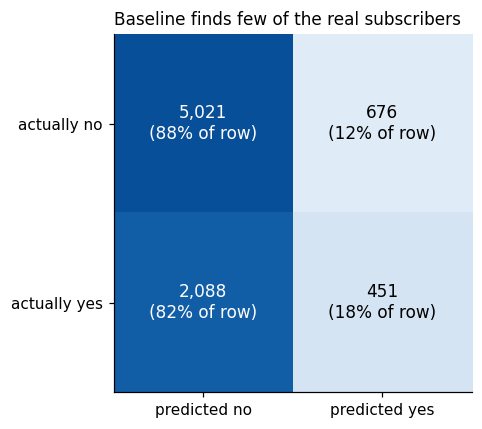

recall 0.178  precision 0.400  |  clients predicted 'yes': 13.7%   actual 'yes': 30.8%


In [5]:
m = results["chronological", "XGBoost"]["test"]
cm = np.array([[m["tn"], m["fp"]], [m["fn"], m["tp"]]])
fig, ax = plt.subplots(figsize=(5, 4))
ax.grid(False)
ax.imshow(cm / cm.sum(axis=1, keepdims=True), cmap="Blues", vmin=0, vmax=1)
for i in range(2):
    for j in range(2):
        share = cm[i, j] / cm[i].sum()
        ax.text(j, i, f"{cm[i, j]:,}\n({share:.0%} of row)", ha="center", va="center", fontsize=11,
                color="white" if share > 0.5 else "black")
ax.set_xticks([0, 1], ["predicted no", "predicted yes"])
ax.set_yticks([0, 1], ["actually no", "actually yes"])
ax.set_title("Baseline finds few of the real subscribers", loc="left", fontsize=11)
save_fig("baseline_confusion_chronological")
print(f"recall {m['recall']:.3f}  precision {m['precision']:.3f}  |  clients predicted 'yes': {(m['tp'] + m['fp']) / cm.sum():.1%}   actual 'yes': {(m['tp'] + m['fn']) / cm.sum():.1%}")

### Insight -> decision

- Finding: at threshold 0.5 the baseline flags only about 14% of test clients as "yes" although 31% really are, so it finds **18% of the true subscribers** (recall) with 40% precision.
- Decision: the threshold 0.5 is not meaningful yet. Choosing an operating threshold belongs to the final model (Member 1's threshold tuning), not to this baseline.
- Reason: the training part has only 6.4% subscribers, so the model's probabilities are low for the much richer test period.

## 4. Why is the chronological score so low? (a check that does not touch the test set)

The test set must stay untouched, so we look inside the **training** part instead: train on its first 75% and validate on the *last 25%* (still in date order). If the drop is caused by time, every model should struggle on this forward-looking block, not only XGBoost.

In [6]:
X_a, X_v, y_a, y_v = chronological_split(X_tr_c, y_tr_c, test_fraction=0.25)     # inner, time-ordered split of the TRAINING part
MACRO = ["emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]
spw_a = compute_scale_pos_weight(y_a)

variants = {
    "Logistic Regression": (build_lr_pipeline(), X_a, X_v),
    "XGBoost (default)": (build_xgb_pipeline(spw_a), X_a, X_v),
    "XGBoost (default), without the 5 macro columns": (build_xgb_pipeline(spw_a), X_a.drop(columns=MACRO), X_v.drop(columns=MACRO)),
}
rows = []
for name, (pipe, Xa_, Xv_) in variants.items():
    p = pipe.fit(Xa_, y_a).predict_proba(Xv_)[:, 1]
    r = evaluate_at_threshold(y_v, p)
    rows.append({"model": name, "PR-AUC": r["pr_auc"], "ROC-AUC": r["roc_auc"]})
print(f"inner train: {len(X_a):,} rows, yes-rate {y_a.mean():.2%}   |   inner validation: {len(X_v):,} rows, yes-rate {y_v.mean():.2%} (floor PR-AUC {y_v.mean():.3f})")
pd.DataFrame(rows).set_index("model")

inner train: 24,705 rows, yes-rate 4.81%   |   inner validation: 8,235 rows, yes-rate 11.07% (floor PR-AUC 0.111)


,PR-AUC,ROC-AUC
model,,
Logistic Regression,0.0995,0.4901
XGBoost (default),0.1173,0.5100
"XGBoost (default), without the 5 macro columns",0.1215,0.5367


In [7]:
# Feature ranges only (no labels): where do the economic indicators lie in each period?
fmt = lambda s: f"{s.min():,.2f} to {s.max():,.2f}"
pd.DataFrame({"inner train (oldest 60% of rows)": [fmt(X_a[c]) for c in ["euribor3m", "nr.employed"]],
              "inner validation (next 20%)": [fmt(X_v[c]) for c in ["euribor3m", "nr.employed"]],
              "test period (newest 20%)": [fmt(X_te_c[c]) for c in ["euribor3m", "nr.employed"]]},
             index=["euribor3m", "nr.employed"])

,inner train (oldest 60% of rows),inner validation (next 20%),test period (newest 20%)
euribor3m,4.19 to 5.04,1.30 to 4.19,0.63 to 1.30
nr.employed,"5,191.00 to 5,228.10","5,099.10 to 5,195.80","4,963.60 to 5,099.10"


### Insight -> decision

- Finding: on the forward-looking validation block **all models are at chance level** - ROC-AUC between 0.49 and 0.54, and PR-AUC close to the floor of 0.111 - including Logistic Regression. So the weak chronological result is **not specific to XGBoost**.
- Finding: the economic indicators barely overlap between periods (for example `euribor3m` is 4.2-5.0 in the oldest rows, 1.3-4.2 next, and 0.6-1.3 in the test period). These columns act almost like a clock, and a tree model cannot predict outside the value ranges it saw in training; a linear model can extrapolate, which is a plausible reason Logistic Regression holds up better on the test period.
- Decision: (1) report **both** splits, as the proposal says; (2) tune with stratified CV inside the training part, as planned, but state clearly that the CV score is optimistic for future campaigns; (3) pass the observation about the macro columns to Member 4 (feature selection).
- Reason / what we do NOT claim: removing the macro columns changed the score only by noise (0.121 vs 0.117 PR-AUC, when every model is at chance), so we do not claim it fixes the problem.

## 5. Record the baseline in the experiment log

The two XGBoost baseline rows are appended to `results/experiment_log.csv` (same columns as Member 1's rows). The cell adds a row only if a row with the same model name is not already in the log, so running the notebook twice does not create duplicates. The stratified row has its own name because it is **not comparable** with the chronological rows.

In [8]:
LOG_RESULTS = True

def log_row(split, model_name, notes):
    """Build one experiment_log row from the results dictionary."""
    r = results[split, "XGBoost"]
    spw = compute_scale_pos_weight(y_tr_c if split == "chronological" else y_tr_s)
    return {"model": model_name, "params": f"defaults;scale_pos_weight={spw:.2f}",
            "cv_pr_auc": round(r["cv"]["cv_pr_auc_mean"], 4), "test_pr_auc": round(r["test"]["pr_auc"], 4),
            "test_roc_auc": round(r["test"]["roc_auc"], 4), "recall": round(r["test"]["recall"], 4),
            "precision": round(r["test"]["precision"], 4), "f1": round(r["test"]["f1"], 4), "notes": notes}

new_rows = [log_row("chronological", "XGBoost (baseline)", "Member 3; chronological hold-out (primary); threshold 0.5"),
            log_row("stratified", "XGBoost (baseline, stratified split)",
                    "Member 3; stratified split (secondary); threshold 0.5; not comparable with chronological rows")]

existing = pd.read_csv(EXPERIMENT_LOG)
to_add = [r for r in new_rows if r["model"] not in set(existing["model"])]
if LOG_RESULTS and to_add:
    with open(EXPERIMENT_LOG, "rb+") as f:                     # make sure the file ends with a newline before appending
        f.seek(-1, 2)
        if f.read(1) != b"\n":
            f.write(b"\n")
    with open(EXPERIMENT_LOG, "a", newline="", encoding="utf-8") as f:
        csv.DictWriter(f, fieldnames=list(existing.columns), lineterminator="\n").writerows(to_add)
print(f"added {len(to_add)} row(s); log now has {len(pd.read_csv(EXPERIMENT_LOG))} rows")
pd.read_csv(EXPERIMENT_LOG).tail(4)

added 0 row(s); log now has 6 rows


,model,params,cv_pr_auc,test_pr_auc,test_roc_auc,recall,precision,f1,notes
2,LogisticRegression (baseline),C=1;l2;class_weight=balanced,0.2027,0.5052,0.7007,0.8476,0.3599,0.5053,Member 1; threshold 0.5
3,LogisticRegression (tuned),{'clf__C': 1; 'clf__l1_ratio': 0.0},0.2027,0.5052,0.7007,0.8476,0.3599,0.5053,Member 1; threshold 0.5; best-F1 thr 0.720; 20...
4,XGBoost (baseline),defaults;scale_pos_weight=14.69,0.1805,0.3666,0.5612,0.1776,0.4002,0.2460,Member 3; chronological hold-out (primary); th...
5,"XGBoost (baseline, stratified split)",defaults;scale_pos_weight=7.88,0.4270,0.4536,0.7954,0.6336,0.3836,0.4779,Member 3; stratified split (secondary); thresh...


## Part 1 summary

| | Chronological (primary) | Stratified (secondary) |
|---|---|---|
| XGBoost baseline, test PR-AUC | 0.367 | 0.454 |
| Logistic Regression baseline, test PR-AUC | 0.505 | 0.447 |
| Random-classifier floor | 0.308 | 0.113 |

* The pipeline is correct (stratified CV of 0.427 is the expected value), and the untuned XGBoost is **not** better than Logistic Regression yet.
* The chronological result is limited by temporal shift, which affects all models, not only XGBoost.

*Part 2 (next): hyperparameter tuning with RandomizedSearchCV and Optuna, then comparison with these baselines.*